## Objective
The goal of this project is to analyze student data to understand the relationship between **acquisition channels** (e.g., Twitter, Instagram, Friends) and **learning engagement** (measured by minutes watched and Customer Lifetime Value - CLV). By applying clustering algorithms, we aim to segment students into meaningful groups and generate insights that can guide marketing resource allocation.

## Dataset
The dataset is provided as a CSV file from 365 Data Science’s database. It combines:
- **Acquisition Channel** (source of student onboarding)
- **Survey Answers** (responses from the onboarding survey)
- **Minutes Watched** 
- **Customer Lifetime Value (CLV)**
- **Country Region**

## Methodology
1. **Data Loading & Exploration**  
   Load the dataset, inspect its structure, and identify data types and missing values.

2. **Data Cleaning & Preprocessing**  
   - Fill missing values in `minutes_watched` with 0.  
   - Create dummy variables for categorical features (`survey_answers`, `country_region`).  
   - Remove the original `survey_answers` column but keep the original `country_region`.

3. **Feature Engineering & Correlation Analysis**  
   - Perform correlation analysis to identify relationships between variables.  
   - Visualize correlations using a heatmap.  
   - Optionally, use scatter plots (e.g., CLV vs. minutes watched) to explore data spread.

4. **Clustering Implementation**  
   - Standardize the data using `StandardScaler`.  
   - Apply **Hierarchical Clustering** (Ward’s method).  
   - Apply **K-means Clustering** and determine the optimal number of clusters using the Elbow Method.  
   - Compare results and select the most meaningful segmentation.

5. **Insights & Recommendations**  
   Interpret clustering results to answer key questions:  
   - Are Twitter groups more or less likely to study compared to Instagram?  
   - Do U.S. students tend to join via friends or social media?  
   - Which acquisition channels bring higher-value customers (higher CLV)?

## Expected Outcome
- Clear segmentation of students based on acquisition channel, engagement, and CLV.  
- Actionable insights for the marketing team to identify the most effective channels for investment.  


In [2]:
import pandas as pd 

In [3]:
df = pd.read_csv('customer_segmentation_data.csv')
df.head()

,minutes_watched,CLV,region,channel
0,3197.0,205.42,2,4
1,63.0,149.99,0,1
2,605.0,119.00,2,2
3,20.0,240.00,2,4
4,245.0,184.36,1,4


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3834 entries, 0 to 3833
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   minutes_watched  3725 non-null   float64
 1   CLV              3834 non-null   float64
 2   region           3834 non-null   int64  
 3   channel          3834 non-null   int64  
dtypes: float64(2), int64(2)
memory usage: 119.9 KB


In [5]:
df. isnull(). sum()

minutes_watched    109
CLV                  0
region               0
channel              0
dtype: int64

## Data Cleaning & preprocessing 

In [7]:
df['minutes_watched'] =df['minutes_watched'].fillna(0)

In [8]:
# Create dummy variables for country_region
df=pd.get_dummies(df, columns=['region'], drop_first= True)

In [9]:
import seaborn as sns 
import matplotlib.pyplot as plt 

# Correlation matrix 
+1 → Strong positive correlation (when the value of one variable increases, the other one increases).

-1 → Strong negative correlation (when the value of one variable increases, the other one decreases).

0 → No clear relationship.

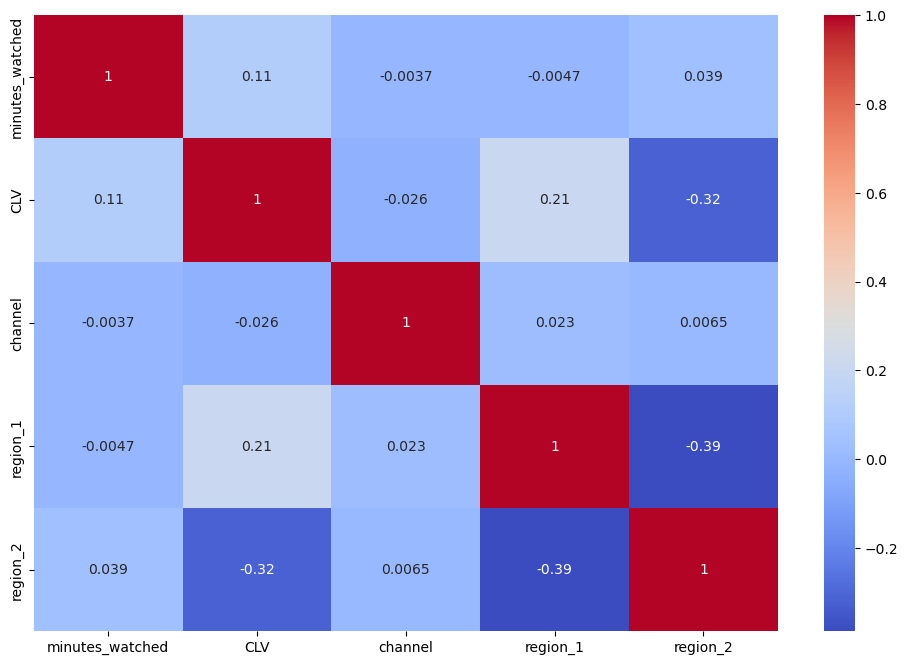

In [11]:
corr= df.corr()
plt.figure (figsize=(12,8))
sns.heatmap(corr, annot = True, cmap='coolwarm')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

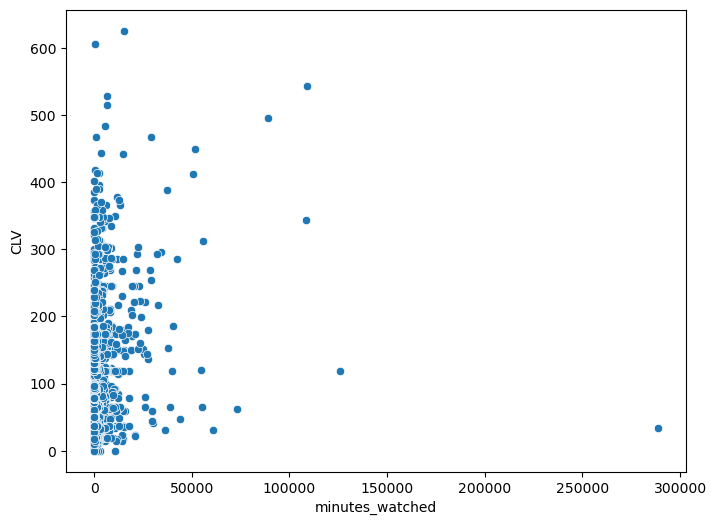

In [12]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='minutes_watched', y='CLV', data = df)
plt.show 

## Standardization
Mean of zero and std of 1 

In [14]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(df.select_dtypes(include=['float64','int64']))

## Hierarchical Clustering 

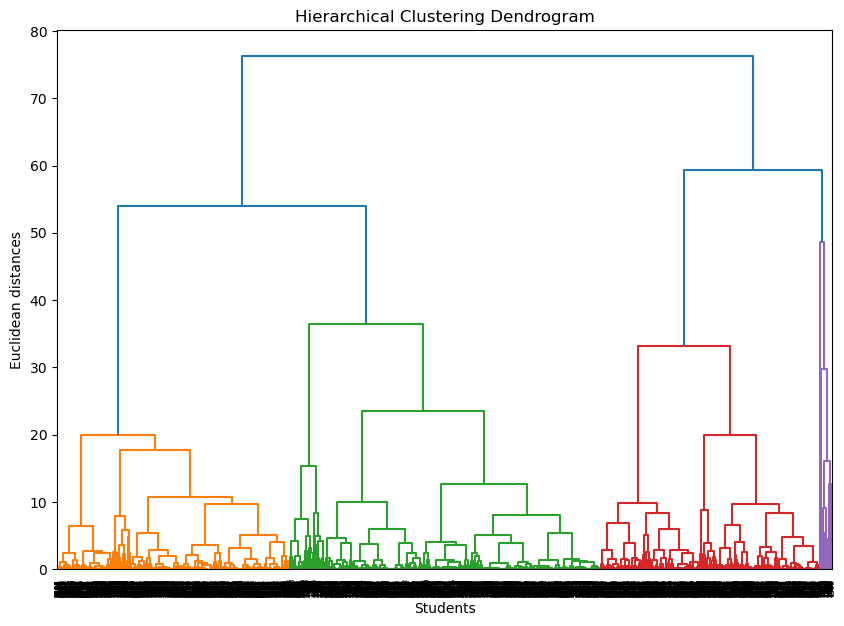

In [17]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
dendrogram = sch.dendrogram(sch.linkage(x_scaled, method='ward'))
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Students")
plt.ylabel("Euclidean distances")
plt.show()

#### Next, you must perform k-means segmentation. Here, you won’t be able to predetermine the correct number of clusters, so you must explore varying clusters and use the elbow method to determine the best possible solution.

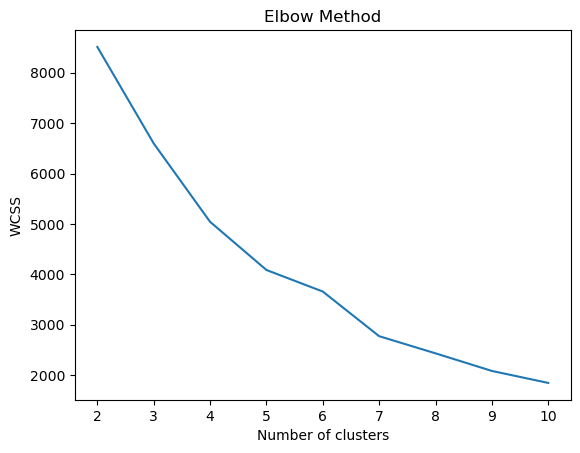

In [38]:
from sklearn.cluster import KMeans

wcss = []
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(x_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(2, 11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()
    

## Choosing the Optimal Number of Clusters

In [43]:
optimal_clusters = 4
Kmeans =KMeans(n_clusters=optimal_clusters, random_state=42)
df['cluster'] = Kmeans.fit_predict(x_scaled)

In [57]:
summary = df.groupby('cluster').agg({
    'minutes_watched' : 'mean',
    'CLV':'mean',
     'region_1':'value_counts',
    'channel':'value_counts'})

In [59]:
summary['proportion']=df['cluster'].value_counts(normalize=True).sort_index()
print(summary)

            minutes_watched         CLV  region_1  channel  proportion
0               1580.622430  165.266791       NaN      NaN    0.418623
1               1568.692308  112.865147       NaN      NaN    0.274648
2              72930.500000  214.950000       NaN      NaN    0.005216
3               1469.472318   56.647708       NaN      NaN    0.301513
(0, False)              NaN         NaN    1345.0      NaN         NaN
(0, True)               NaN         NaN     260.0    380.0         NaN
(1, False)              NaN         NaN     907.0      NaN         NaN
(1, True)               NaN         NaN     146.0      NaN         NaN
(2, False)              NaN         NaN      20.0      NaN         NaN
(3, False)              NaN         NaN    1101.0      NaN         NaN
(3, True)               NaN         NaN      55.0    289.0         NaN
(0, 3)                  NaN         NaN       NaN    675.0         NaN
(0, 4)                  NaN         NaN       NaN    364.0         NaN
(0, 2)

## Conclusion
The customer segmentation analysis revealed four distinct clusters of learners, each with unique engagement levels, customer lifetime values (CLV), and acquisition patterns. By combining hierarchical clustering and k-means, we identified meaningful groups that highlight both high-value customers and underperforming segments.

From a marketing perspective, LinkedIn, Google, and YouTube emerged as strong acquisition channels, consistently attracting engaged learners with higher CLVs. Conversely, Twitter and Instagram showed weaker performance, often associated with lower engagement and reduced customer value. Regionally, Anglo-Saxon markets responded well to professional channels such as LinkedIn and Google, while European customers were more likely to engage through YouTube and Google.

These insights suggest a clear strategy: increase marketing investment in high-performing channels and regions, optimize or reconsider spend on weaker channels, and design tailored retention programs for each cluster. For example, loyalty initiatives could strengthen relationships with high-value “Power Users,” while targeted engagement campaigns could improve outcomes for low-value social media segments.

Ultimately, this segmentation provides actionable guidance for resource allocation, enabling the marketing team to maximize ROI by focusing on the most effective channels and customer groups.